# Setup

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [2]:
from rich import print
import pandas as pd
import matplotlib.pyplot as plt



from tpvalidator.viz.tps import TrgPrimitivesPlotter



# Data

In [3]:
import tpvalidator.datacatalogue as dctl

dataset_names = ['eminus', 'radbkg']
# datasets = dctl.load('data/vd/1x8x14/3sig', load_rawadc=False, selection=dataset_names)
# datasets = dctl.load('data/vd/1x8x14/preprod', load_rawadc=False, selection=dataset_names)
datasets = dctl.load('data/vd/1x8x14/filtered', load_rawadc=False, selection=dataset_names)
rad_ws=datasets['radbkg']
em_ws=datasets['eminus']


Loading eminus

Key 'mcneutrinos' not found in file.
Key 'mcparticles' not found in file.
Key 'simides' not found in file.


Dataset 'eminus': 10000 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 36,
            'threshold_tpg_plane1': 36,
            'threshold_tpg_plane2': 36,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Workspace radbkg_10 skipped

Workspace radbkg_1000 skipped

Workspace radbkg_5000 skipped

Loading radbkg

Dataset 'radbkg': 1000 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [
        [28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
        [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
        [26, 'Kr85GenInLAr'],
        [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
        [24, 'U238ChainGenInAnode'],
        [23, 'K40GenInCathode'],
        [22, 'K42From42ArGenInUpperMesh1x8x14'],
        [21, 'Th232ChainGenInCathode'],
        [20, 'CavernNGammasAtLAr1x8x14'],
        [19, 'Rn222ChainRn222GenInLAr'],
        [18, 'U238ChainGenInCathode'],
        [17, 'K40GenInAnode'],
        [16, 'Rn220ChainPb212GenInLAr'],
        [15, 'foamGammasAtLAr1x8x14'],
        [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
        [13, 'K42From42ArGenInLAr'],
        [12, 'Rn222ChainGenInPDS'],
        [11, 'Ar42GenInLAr'],
        [10, 'CavernwallGammasAtLAr1x8x14'],
        [9, 'Rn222ChainPb210GenInLAr'],
        [8, 'Ar39GenInLAr'],
        [7, 'Rn222ChainPb214GenInLAr'],
        [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
        [5, 'Rn222ChainPo218GenInLAr'],
        [4, 'CavernwallNeutronsAtLAr1x8x14'],
        [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
        [2, 'CryostatNGammasAtLAr1x8x14'],
        [1, 'Th232ChainGenInAnode'],
        [0, 'Rn222ChainBi214GenInLAr']
    ],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 36,
            'threshold_tpg_plane1': 36,
            'threshold_tpg_plane2': 36,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

In [4]:
rad_ws.info['mctruth_blockid_map']

[[28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
 [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
 [26, 'Kr85GenInLAr'],
 [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
 [24, 'U238ChainGenInAnode'],
 [23, 'K40GenInCathode'],
 [22, 'K42From42ArGenInUpperMesh1x8x14'],
 [21, 'Th232ChainGenInCathode'],
 [20, 'CavernNGammasAtLAr1x8x14'],
 [19, 'Rn222ChainRn222GenInLAr'],
 [18, 'U238ChainGenInCathode'],
 [17, 'K40GenInAnode'],
 [16, 'Rn220ChainPb212GenInLAr'],
 [15, 'foamGammasAtLAr1x8x14'],
 [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
 [13, 'K42From42ArGenInLAr'],
 [12, 'Rn222ChainGenInPDS'],
 [11, 'Ar42GenInLAr'],
 [10, 'CavernwallGammasAtLAr1x8x14'],
 [9, 'Rn222ChainPb210GenInLAr'],
 [8, 'Ar39GenInLAr'],
 [7, 'Rn222ChainPb214GenInLAr'],
 [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
 [5, 'Rn222ChainPo218GenInLAr'],
 [4, 'CavernwallNeutronsAtLAr1x8x14'],
 [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
 [2, 'CryostatNGammasAtLAr1x8x14'],
 [1, 'Th232ChainGenInAnode'],
 [0, 'Rn222

# Pre-Run Checks

## Background and Signal TPs properties
A routine check to confirm the absense of macroscopic features in the input datasets, and that the samples were properly filtered.

Min samples_over_threshold = 9

Min adc_peak = 46

Min adc_integral = 353

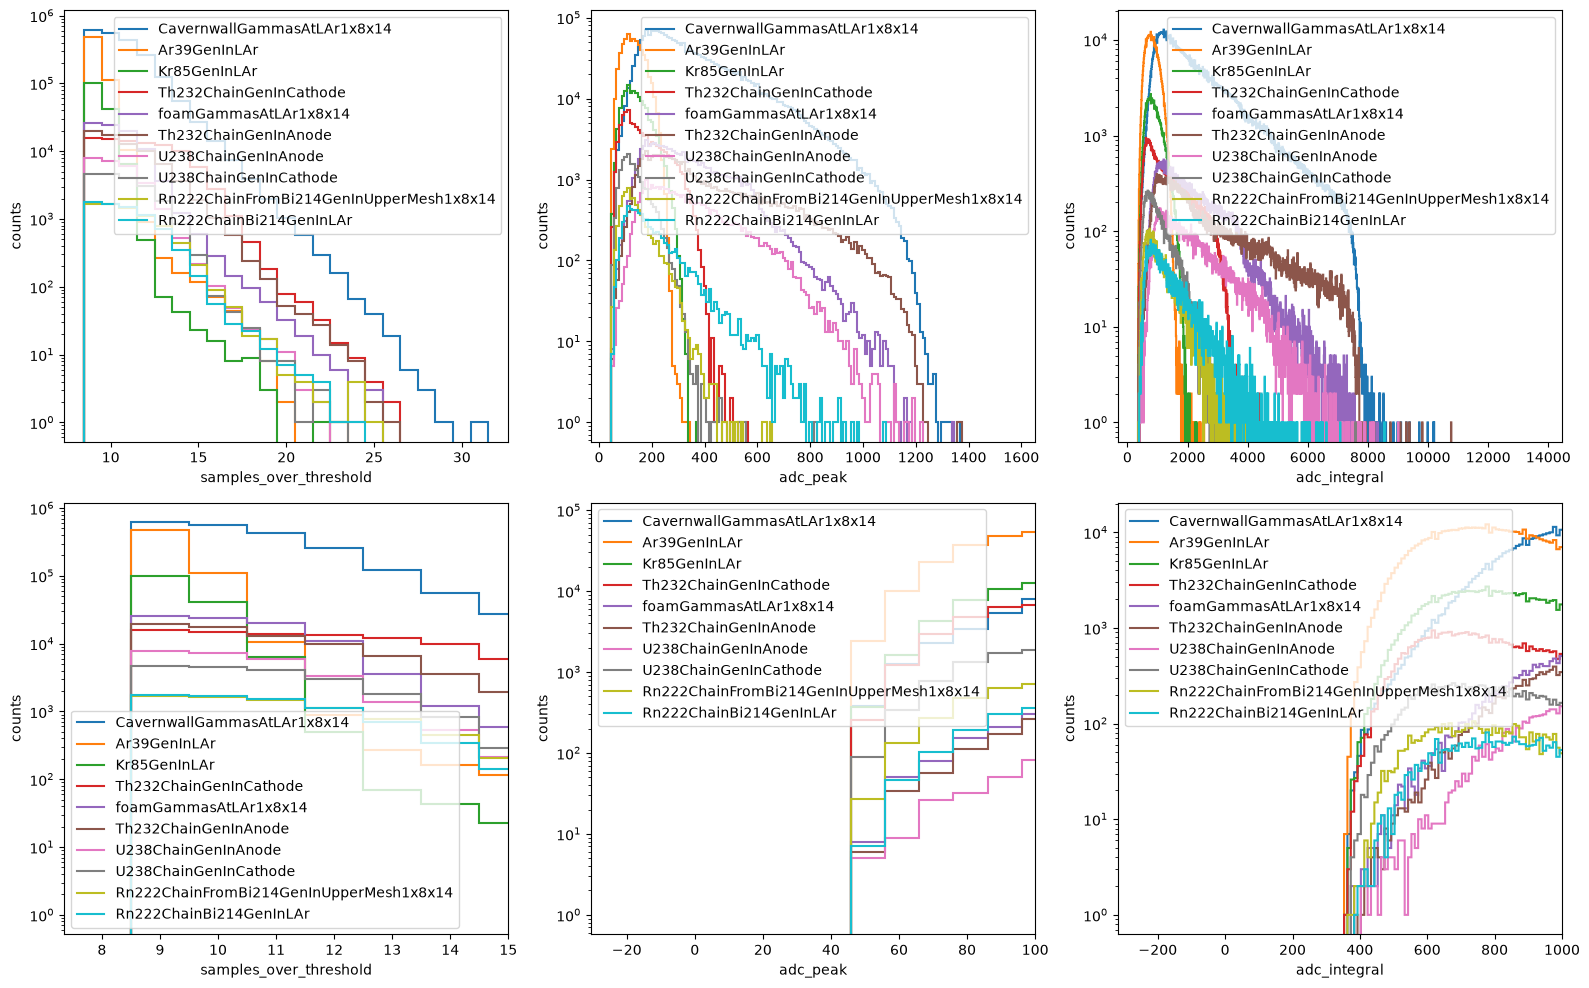

In [5]:
query=None
norm='rate'
geo_norm='crp'
n_top=10
rop=2


bkg_tpp = TrgPrimitivesPlotter(rad_ws)

fig, axes = plt.subplots(2, 3, figsize=(16,10))

bkg_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='samples_over_threshold', ax=axes[0][0])
bkg_tpp.plot_var_by_generator(query=query, rop=rop,n_top=n_top, var_spec='adc_peak', ax=axes[0][1])
bkg_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='adc_integral', ax=axes[0][2])

bkg_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='samples_over_threshold', ax=axes[1][0])
axes[1][0].set_xlim(xmax=15)

bkg_tpp.plot_var_by_generator(query=query, rop=rop,n_top=n_top, var_spec='adc_peak', ax=axes[1][1])
axes[1][1].set_xlim(xmax=100)

bkg_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='adc_integral', ax=axes[1][2])
axes[1][2].set_xlim(xmax=1000)


fig.tight_layout()

print(f"Min samples_over_threshold = {rad_ws.tps.samples_over_threshold.min()}")
print(f"Min adc_peak = {rad_ws.tps.adc_peak.min()}")
print(f"Min adc_integral = {rad_ws.tps.adc_integral.min()}")



Min samples_over_threshold = 9

Min adc_peak = 46

Min adc_integral = 353

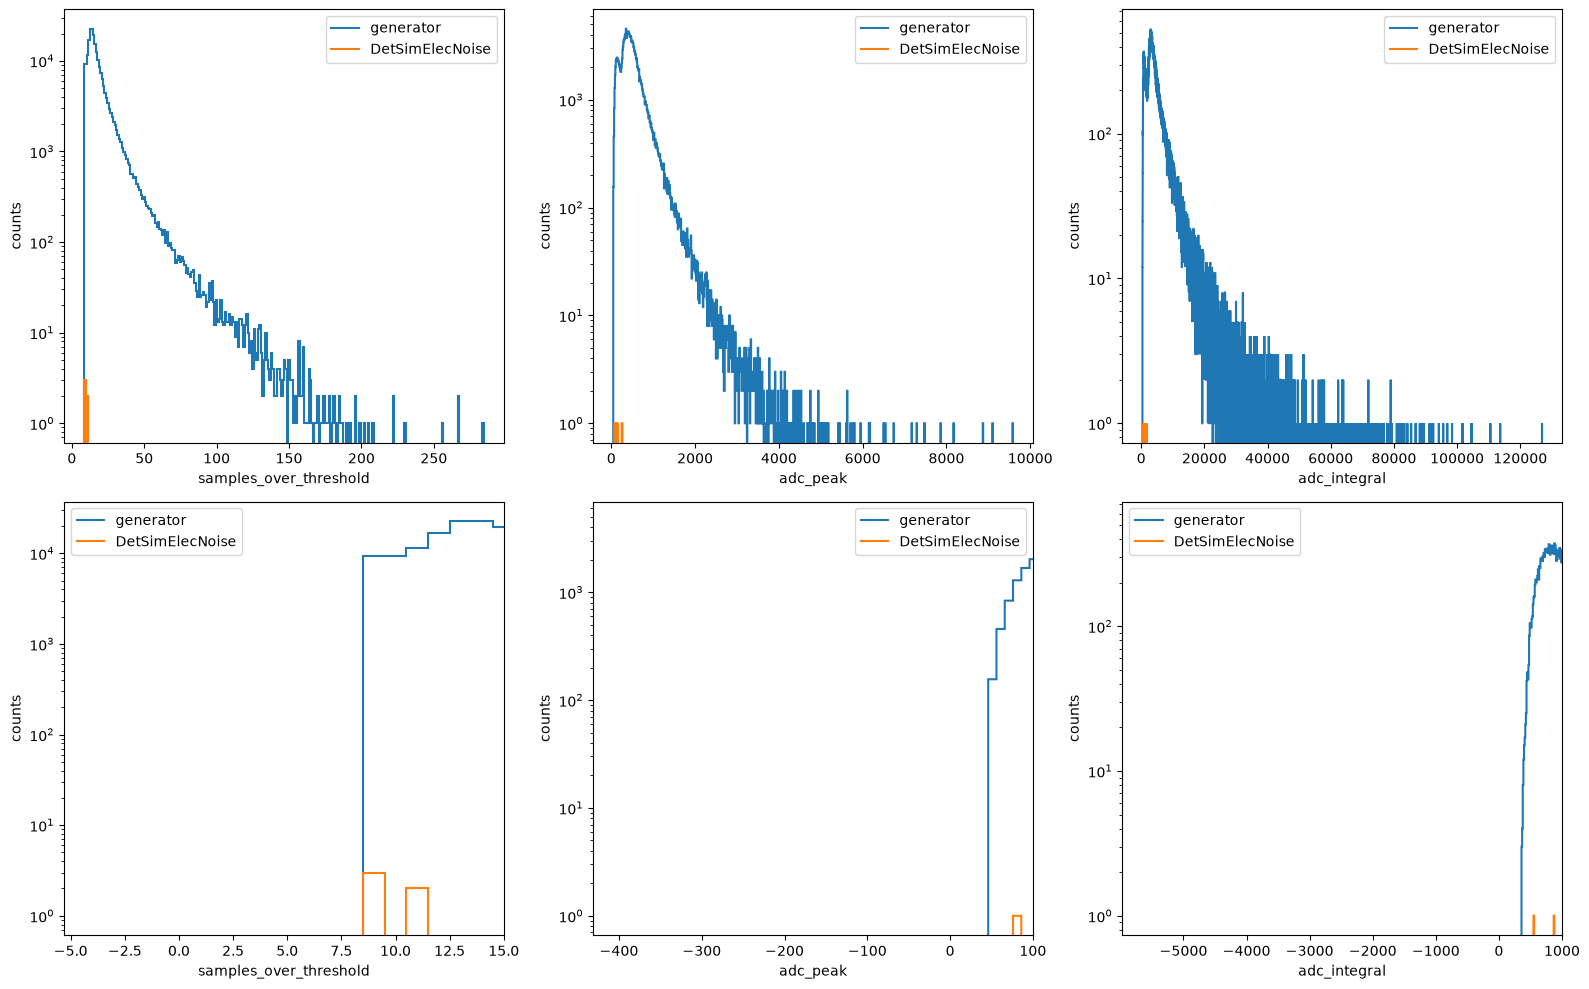

In [6]:
sig_tpp = TrgPrimitivesPlotter(em_ws)

fig, axes = plt.subplots(2, 3, figsize=(16,10))

sig_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='samples_over_threshold', ax=axes[0][0])
sig_tpp.plot_var_by_generator(query=query, rop=rop,n_top=n_top, var_spec='adc_peak', ax=axes[0][1])
sig_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='adc_integral', ax=axes[0][2])

sig_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='samples_over_threshold', ax=axes[1][0])
axes[1][0].set_xlim(xmax=15)

sig_tpp.plot_var_by_generator(query=query, rop=rop,n_top=n_top, var_spec='adc_peak', ax=axes[1][1])
axes[1][1].set_xlim(xmax=100)

sig_tpp.plot_var_by_generator(query=query, rop=rop, n_top=n_top, var_spec='adc_integral', ax=axes[1][2])
axes[1][2].set_xlim(xmax=1000)


fig.tight_layout()

print(f"Min samples_over_threshold = {rad_ws.tps.samples_over_threshold.min()}")
print(f"Min adc_peak = {rad_ws.tps.adc_peak.min()}")
print(f"Min adc_integral = {rad_ws.tps.adc_integral.min()}")

In [7]:
bkg_tpp.make_generator_activity_table(geo_norm='crp')

                                       Rates per generator (crp)                                       
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃    ┃ generator                               ┃ rate        ┃ rate_rop0  ┃ rate_rop1   ┃ rate_rop2   ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 3  │ CavernwallGammasAtLAr1x8x14             │ 33990.08 Hz │ 1214.97 Hz │ 15092.91 Hz │ 17682.19 Hz │
│ 1  │ Ar39GenInLAr                            │ 6045.71 Hz  │ 2.37 Hz    │ 984.61 Hz   │ 5058.73 Hz  │
│ 10 │ Kr85GenInLAr                            │ 1610.43 Hz  │ 0.71 Hz    │ 350.03 Hz   │ 1259.70 Hz  │
│ 22 │ Th232ChainGenInCathode                  │ 1457.51 Hz  │ 247.04 Hz  │ 447.18 Hz   │ 763.29 Hz   │
│ 25 │ foamGammasAtLAr1x8x14                   │ 1380.86 Hz  │ 25.95 Hz   │ 624.34 Hz   │ 730.57 Hz   │
│ 21 │ Th232ChainGenInAnode                    │ 1248.80 Hz  │ 86.01 Hz   │ 540.96 Hz   │ 621.83 Hz   │
│ 0  │ DetSimElecNoise                         │ 947.56 Hz   │ 92.29 Hz   │ 853.50 Hz   │ 1.76 Hz     │
│ 23 │ U238ChainGenInAnode                     │ 429.27 Hz   │ 10.96 Hz   │ 193.31 Hz   │ 225.00 Hz   │
│ 24 │ U238ChainGenInCathode                   │ 258.18 Hz   │ 22.46 Hz   │ 72.98 Hz    │ 162.73 Hz   │
│ 13 │ Rn222ChainBi214GenInLAr                 │ 112.37 Hz   │ 9.03 Hz    │ 40.81 Hz    │ 62.53 Hz    │
│ 11 │ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 106.04 Hz   │ 16.03 Hz   │ 32.85 Hz    │ 57.16 Hz    │
│ 15 │ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 104.84 Hz   │ 11.55 Hz   │ 30.20 Hz    │ 63.08 Hz    │
│ 6  │ K40GenInAnode                           │ 97.11 Hz    │ 0.44 Hz    │ 44.55 Hz    │ 52.13 Hz    │
│ 12 │ Rn220ChainPb212GenInLAr                 │ 68.65 Hz    │ 8.45 Hz    │ 25.46 Hz    │ 34.74 Hz    │
│ 7  │ K40GenInCathode                         │ 45.50 Hz    │ 2.06 Hz    │ 12.60 Hz    │ 30.84 Hz    │
│ 9  │ K42From42ArGenInUpperMesh1x8x14         │ 22.26 Hz    │ 4.15 Hz    │ 7.18 Hz     │ 10.93 Hz    │
│ 19 │ Rn222ChainPb214GenInLAr                 │ 12.20 Hz    │ 0.00 Hz    │ 2.92 Hz     │ 9.29 Hz     │
│ 14 │ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 11.75 Hz    │ 0.10 Hz    │ 1.74 Hz     │ 9.91 Hz     │
│ 8  │ K42From42ArGenInLAr                     │ 5.95 Hz     │ 0.96 Hz    │ 2.16 Hz     │ 2.83 Hz     │
│ 17 │ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 2.17 Hz     │ 0.02 Hz    │ 0.18 Hz     │ 1.97 Hz     │
│ 2  │ Ar42GenInLAr                            │ 1.03 Hz     │ 0.00 Hz    │ 0.21 Hz     │ 0.82 Hz     │
│ 5  │ CryostatNGammasAtLAr1x8x14              │ 0.50 Hz     │ 0.11 Hz    │ 0.17 Hz     │ 0.22 Hz     │
│ 4  │ CavernwallNeutronsAtLAr1x8x14           │ 0.40 Hz     │ 0.01 Hz    │ 0.18 Hz     │ 0.22 Hz     │
│ 18 │ Rn222ChainPb210GenInLAr                 │ 0.01 Hz     │ 0.00 Hz    │ 0.01 Hz     │ 0.00 Hz     │
│ 20 │ Rn222ChainRn222GenInLAr                 │ 0.01 Hz     │ 0.00 Hz    │ 0.00 Hz     │ 0.01 Hz     │
│ 16 │ Rn222ChainFromPb210GenInUpperMesh1x8x14 │ 0.01 Hz     │ 0.00 Hz    │ 0.01 Hz     │ 0.00 Hz     │
└────┴─────────────────────────────────────────┴─────────────┴────────────┴─────────────┴─────────────┘

---

# Analyzer

In [8]:

import hist
import mplhep as hep
import copy

from tpvalidator.detgeometry import get_by_geocfg_id

from typing import Optional
from tpvalidator.analysis.histograms import compute_regaxis_specs, cumsum_hist_nd, build_histogram, make_intcat_axis, make_strcat_axis

def make_wins(tps: pd.DataFrame):
    summary = (
        tps
        .groupby(['event_uid', 'TPCSetID', 'readout_plane_id','tawin_id'], observed=False, sort=False)
        .agg(
            n_tps=('tawin_id', "size"),
            sadc=("adc_integral", "sum"),
        )
        .reset_index()
    )

    return summary


class Calibrator:

    def __init__(self, m, b):
        self.m = m
        self.b = b
        
    def sadc_to_mev(self, sadc ):
        mev = sadc/self.m-self.b/self.m
        return mev

    def mev_to_sadc(self, mev ):
        sadc = self.m*mev+self.b
        return sadc


# TODO: Move to a dedicated module
class TrgWorkspaceAnalyzer:
    """Base class for analysers

    Returns:
        _type_: _description_
    """

    #-----------
    def __init__(self, ws):
        
        self.ws = ws
 
       # Initialize geometry
        self._geo = get_by_geocfg_id(ws.info['geo']['detector'])

    def simulated_readout_time(self) -> float:
        """Return total simulated time in seconds.

        Computed as ``2 × readout_window × num_entries × 0.5 µs``, where the
        factor of 2 accounts for pre- and post-spill readout windows.
        Always derived from ``ws.mctruths`` regardless of the active
        collection.
        """
        
        sampling_time = 0.5e-6  # Sampling time 1/2 usec
        ro_win = self.ws.extra_info['detector_properties']['readout_window']
        num_entries = self.ws.num_entries
        return ro_win * sampling_time * num_entries

    

    @property
    def geo(self):
        return self._geo

class TAWindowAnalyzer(TrgWorkspaceAnalyzer):
    
    #-----------
    def __init__(self, ws, win_len):
        super(TAWindowAnalyzer, self).__init__(ws)

        self.win_len = win_len

        # initialization
        self.tps_in_win = self.ws.tps.copy()
        self.tps_in_win['tawin_id'] = self.tps_in_win.sample_peak // self.win_len

        self.ta_wins = make_wins(self.tps_in_win)

    #-----------
    def _apply_event_filter(self, df, event_filter:dict):
        evf_collection = event_filter['collection']
        evf_filter = event_filter['filter']

        coll = self.ws.get_df(evf_collection)

        ev_uids = coll.query(evf_filter).event_uid.unique()
        df = df[df.event_uid.isin(ev_uids)]

        return df


    #-----------
    def _get_cat_axis_list(self, df:pd.DataFrame, categories: list[str]) -> list[hist.axis.AxisProtocol]:
       
        h_spec = []
        for cat in categories:
            match cat:
                case 'readout_plane_id':
                    rop_axis = make_intcat_axis(df, 'readout_plane_id', label='Readout Plane')
                    h_spec.append(rop_axis)

                # case 'bt_is_signal':
                #     bt_sig_axis = make_intcat_axis(df, 'bt_is_signal', label='Noise/Signal')
                #     h_spec.append(bt_sig_axis)

                # case 'bt_generator_name':
                #     bt_gen_axis = make_strcat_axis(df, 'bt_generator_name', label='Generator')
                #     h_spec.append(bt_gen_axis)

                case _:
                    raise ValueError(f"Category {cat} not known")
                
        return h_spec
    


    #-----------
    def make_tawin_hist(self,
                var_spec:list[dict|str]|dict|str=[],
                categories: list[str]=['readout_plane_id'],
                weight: Optional[str]=None,
                query: Optional[str]=None,
                event_filter: Optional[dict]=None
            ):
        """Build a boost-histogram from the TP dataframe.

        Args:
            var_spec: Variable(s) to histogram. Each entry is either a string key
                into ``self.var_specs`` or a dict with keys ``name``, ``bin_size``,
                and optionally ``label`` and ``type``. A single dict is accepted
                in place of a one-element list.
            categories: Column names to use as categorical axes. Defaults to
                ``['readout_plane_id']``.
            weight: Column name whose values are used as per-entry weights.
            query: Pandas query string applied to the dataframe before filling.
            event_filter: Restrict entries to events that pass a filter on a
                different collection. Dict with keys ``'collection'`` (name passed
                to ``ws.get_df()``) and ``'filter'`` (query string applied to that
                collection); only rows whose ``event_uid`` appears in the filtered
                collection are kept.

        Returns:
            boost_histogram.Histogram with one categorical axis per category and
            one regular axis per variable.
        """
        df = self.ta_wins

        # TODO: generalize
        if event_filter:

            df = self._apply_event_filter(df, event_filter)


        if query:
            df = df.query(query)

        h_spec = self._get_cat_axis_list(df, categories)

        if isinstance(var_spec, dict):
            var_spec = [var_spec]

        for vs in var_spec:
            if isinstance(vs, str):
                vs = self.var_specs.get(vs)

            v_name = vs['name']
            v_bin_size = vs['bin_size']
            v_label = vs.get('label', v_name)
            v_type = vs.get('type', 'float')
            
            n_bins, xmin, xmax = compute_regaxis_specs(df[v_name], v_bin_size, binning_type=v_type)

            var_axis = hist.axis.Regular( n_bins, xmin, xmax, name=v_name, label=v_label)

            h_spec.append(var_axis)

        h = build_histogram(df, h_spec, weight=weight)
        return h

# Analysis

In [9]:
rad_twa = TAWindowAnalyzer(rad_ws, 1000)
em_twa = TAWindowAnalyzer(em_ws, 1000)

In [10]:
elec_calibrator = Calibrator(
    m = 2903.2,
    b = -5400
)

# Check the calibrator consistency
print(f"8000 sadcs -> {elec_calibrator.sadc_to_mev(8000):.2f} MeV")
print(f"5 MeV -> {elec_calibrator.mev_to_sadc(5):.2f} sadc")
print(f"sadc -> mev -> sadc : 8000 -> {elec_calibrator.mev_to_sadc(elec_calibrator.sadc_to_mev(8000))}")

8000 sadcs -> 4.62 MeV

5 MeV -> 9116.00 sadc

sadc -> mev -> sadc : 8000 -> 8000.000000000002

In [11]:
rad_twa.ta_wins.query('readout_plane_id == 2')

,event_uid,TPCSetID,readout_plane_id,tawin_id,n_tps,sadc
9,99010000001,62,2,8,1,795
10,99010000001,62,2,1,4,7024
11,99010000001,62,2,2,7,12769
12,99010000001,62,2,6,1,2467
13,99010000001,62,2,0,4,9650
...,...,...,...,...,...,...
1917223,99010010002,43,2,3,5,12804
1917224,99010010002,43,2,7,6,19591
1917225,99010010002,43,2,2,1,3366
1917226,99010010002,43,2,6,1,3071


## Check windows distributions
- Uniformity
- 

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x120585f90>, errorbar=None, legend_artist=None)]

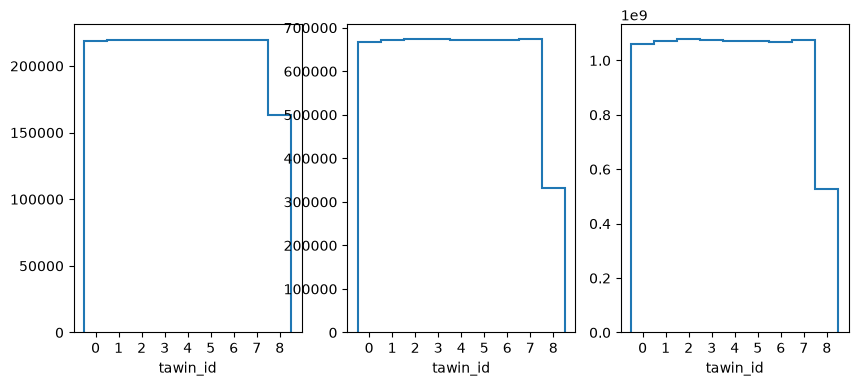

In [12]:
tawin_ax = hist.axis.Integer(0, rad_twa.ta_wins.tawin_id.max()+1, name='tawin_id')

h_tawin = hist.Hist(tawin_ax)
h_tawin.fill(tawin_id=rad_twa.ta_wins.tawin_id.values)

h_tawin_ntps = hist.Hist(tawin_ax)
h_tawin_ntps.fill(tawin_id=rad_twa.ta_wins.tawin_id.values, weight=rad_twa.ta_wins.n_tps)


h_tawin_sadc = hist.Hist(tawin_ax)
h_tawin_sadc.fill(tawin_id=rad_twa.ta_wins.tawin_id.values, weight=rad_twa.ta_wins.sadc)

fig, axes = plt.subplots(1,3, figsize=(10,4))
hep.histplot(h_tawin, ax=axes[0])
hep.histplot(h_tawin_ntps, ax=axes[1])
hep.histplot(h_tawin_sadc, ax=axes[2])



## By readout plane (RadBkg)

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x11ff85160>, cbar=<matplotlib.colorbar.Colorbar object at 0x11ff84d70>, text=[])

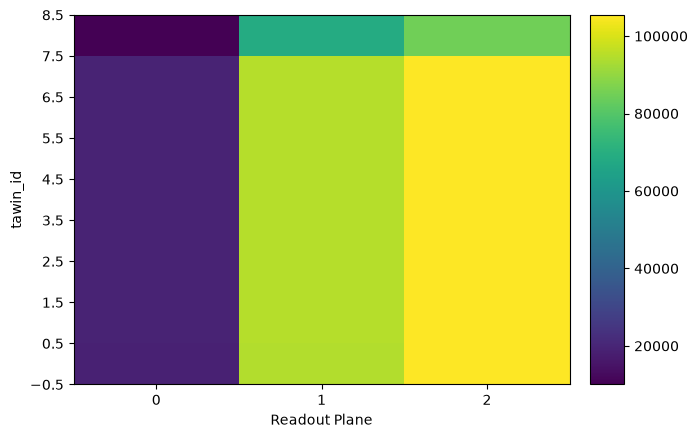

In [13]:
h = rad_twa.make_tawin_hist({'name':'tawin_id', 'bin_size': 1, 'type': 'int'})
hep.hist2dplot(h)

## SumADC and Num TPs for backgrounds and $e^-$

[(3.4435667921875894, 2.004694816822503)]

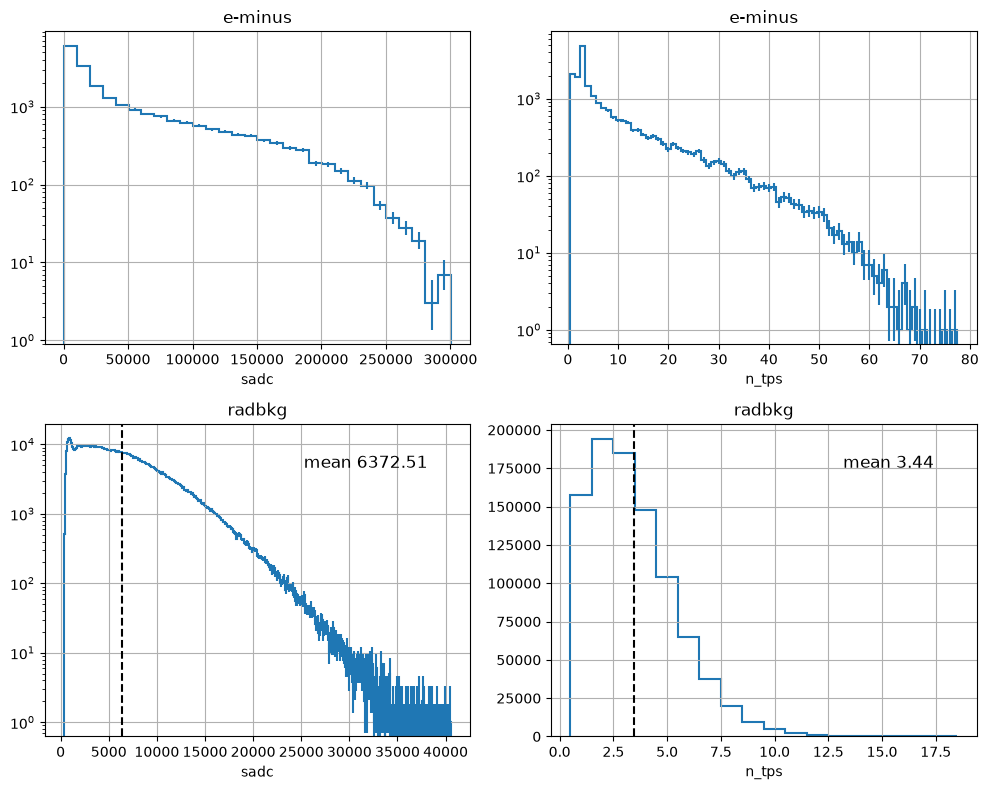

In [14]:
from tpvalidator.analysis.histograms import hist_stats


rop=2j

fig, axes = plt.subplots(2,2, figsize=(10,8))

ax=axes[0][0]
h = em_twa.make_tawin_hist({'name':'sadc', 'bin_size': 10000})
hep.histplot(h[rop,:], ax=ax)
ax.set_yscale('log')
ax.set_title('e-minus')
ax.grid()


ax=axes[0][1]
h = em_twa.make_tawin_hist({'name':'n_tps', 'bin_size': 1, 'type': 'int'})
hep.histplot(h[rop,:], ax=ax)
ax.set_yscale('log')
ax.set_title('e-minus')
ax.grid()

ax=axes[1][0]
h = rad_twa.make_tawin_hist({'name':'sadc', 'bin_size': 100})
hep.histplot(h[rop,:], ax=ax)
ax.set_yscale('log')
ax.set_title('radbkg')
mean, std = hist_stats(h[rop,:])[0]


ax.axvline(mean, c='k', ls='--')
ax.text(0.9, 0.9, f"mean {mean:.2f}", transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='right')
ax.grid()


ax=axes[1][1]
h = rad_twa.make_tawin_hist({'name':'n_tps', 'bin_size': 1, 'type': 'int'})
hep.histplot(h[rop,:], ax=ax)
print(hist_stats(h[rop,:]))
ax.set_title('radbkg')

mean, std = hist_stats(h[rop,:])[0]


ax.axvline(mean, c='k', ls='--')
ax.text(0.9, 0.9, f"mean {mean:.2f}", transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='right')
ax.grid()

fig.tight_layout()

### 2D distributions

In [15]:
h_em = em_twa.make_tawin_hist([{'name':'n_tps', 'bin_size': 1, 'type': 'int'}, {'name':'sadc', 'bin_size': 100}])
h_rad = rad_twa.make_tawin_hist([{'name':'n_tps', 'bin_size': 1, 'type': 'int'}, {'name':'sadc', 'bin_size': 100}])



ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x1243f6850>, cbar=<matplotlib.colorbar.Colorbar object at 0x12443de50>, text=[])

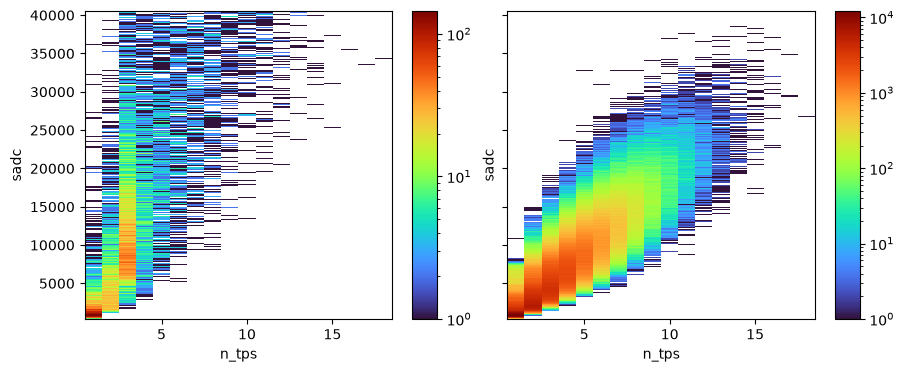

In [16]:
from matplotlib.colors import LogNorm


fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
hep.hist2dplot(h_em[rop,:,:], cmap='turbo', norm=LogNorm(), ax=axes[0])
hep.hist2dplot(h_rad[rop,:,:], cmap='turbo', norm=LogNorm(), ax=axes[1])


## Compare e- max-adc / event with radbkg sadc distro

In [17]:
em_sadc_max = (em_twa.ta_wins
 .groupby('event_uid', sort=False)
 .agg(
    sadc_max=('sadc', "max"),
    n_win=('tawin_id', "size"),
    )
)


rad_sadc_max = (rad_twa.ta_wins
 .groupby('event_uid', sort=False)
 .agg(
    sadc_max=('sadc', "max"),
    n_win=('tawin_id', "size"),
    )
)

display(rad_sadc_max)

,sadc_max,n_win
event_uid,,
99010000001,27249,1904
99010000002,34243,1921
99010000003,24045,1908
99010000004,32314,1909
99010000005,23876,1948
...,...,...
99010009908,27361,1929
99010009909,22241,1892
99010009910,28759,1932


Text(0.5, 1.0, 'radbkg - win sadc')

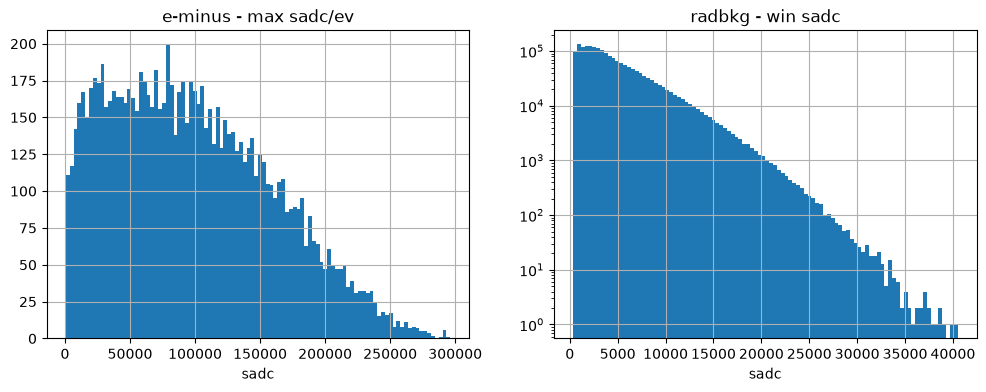

In [18]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

ax=axes[0]
em_sadc_max.sadc_max.hist(bins=100, ax=ax)

ax.set_title('e-minus - max sadc/ev')
ax.set_xlabel('sadc')


ax=axes[1]
rad_twa.ta_wins.sadc.hist(bins=100, ax=ax)
ax.set_yscale('log')
ax.set_xlabel('sadc')
ax.set_title('radbkg - win sadc')

### Observations
- Radiological window have a max sadc value of ~40k
---

## Cluster making

### Define inspect windows and estimate inspect rate

- Select windows with charge above the radbkg average and below the bkg endpoint.
- Check TP multiplicity in inspect windows

┌───────────────────────────────────────────────────┬──────────────┐
│ Window length                                     │ 1000 samples │
│ Window length                                     │ 0.0005 s     │
│ Num CRP                                           │ 28.0         │
│ Simulated readout time                            │ 4.2s         │
│ Number of window expected per TPC                 │ 8500.0       │
│ Number of window expected (total)                 │ 952000.0     │
│ Total number of windows (all planes)              │ 1917228      │
│ Total number of collection windows in the dataset │ 927601       │
│ Number of windows per CRP                         │ 68472.43     │
│ Windows rate per CRP                              │ 16111.16 Hz  │
│ Selected inspect windows                          │ 321511       │
│ Selected inspect windows ratio                    │ 0.17         │
│ Inspect rate per CRP                              │ 2701.77 Hz   │
└───────────────────────────────────────────────────┴──────────────┘

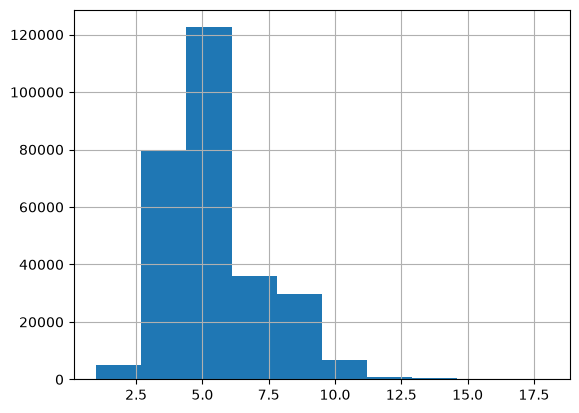

In [19]:
rop =2 
min_sadc = 8000
max_sadc = 50000
rad_insp_win = rad_twa.ta_wins.query(f'sadc > {min_sadc} & sadc < {max_sadc}')

rad_insp_win.query(f'readout_plane_id == {rop}').n_tps.hist()

rows = [
    ("Window length", f"{rad_twa.win_len} samples"),
    ("Window length", f"{rad_twa.win_len*0.5e-6} s"),
    ("Num CRP", f"{rad_twa.geo.num_crps}"),
    ("Simulated readout time", f"{rad_twa.simulated_readout_time():.2}s"),
    ("Number of window expected per TPC", f"{rad_twa.simulated_readout_time()/(rad_twa.win_len*0.5e-6):.1f}"),
    ("Number of window expected (total)", f"{rad_twa.simulated_readout_time()/(rad_twa.win_len*0.5e-6)*rad_twa.geo.num_tpcs:.1f}"),
    ("Total number of windows (all planes)", f"{len(rad_twa.ta_wins)}"),
    ("Total number of collection windows in the dataset", f"{len(rad_twa.ta_wins.query('readout_plane_id == 2'))}"),
    ("Number of windows per CRP", f"{len(rad_twa.ta_wins)/rad_twa.geo.num_crps:.2f}"),
    ("Windows rate per CRP", f"{len(rad_twa.ta_wins)/(rad_twa.geo.num_crps*rad_twa.simulated_readout_time()):.2f} Hz"),


    ("Selected inspect windows",f"{len(rad_insp_win)}"),
    ("Selected inspect windows ratio",f"{len(rad_insp_win)/len(rad_twa.ta_wins):.2f}"),
    ("Inspect rate per CRP", f"{len(rad_insp_win)/(rad_twa.simulated_readout_time()*rad_twa.geo.num_crps):.2f} Hz"),
    # All wins {len(rad_twa.ta_wins)} -> inspect {len(rad_insp_win)} ({len(rad_insp_win)/len(rad_twa.ta_wins):.3})
]

from rich.table import Table
t = Table(show_header=False)

for r in rows:

    t.add_row(r[0], f'[bold]{r[1]}[/bold]')


print(t)

## Collect TPs in the inspect windows and run the clustering algorithm

In [20]:
keys = ['event_uid', 'TPCSetID', 'readout_plane_id', 'tawin_id']
rad_insp_tps = rad_twa.tps_in_win.join(rad_insp_win.assign(_keep=True).set_index(keys), on=keys)

rad_insp_tps

mask  TPCSetID  adc_integral  adc_peak   bt_edep  \
entry subentry                                                     
0     0            0        62           765       122  0.830786   
      1            0        62          3247       581  2.353353   
      2            0        62           565        68  0.284733   
      3            0        62          1676       237  1.036893   
      4            0        62           446        64  0.366180   
...              ...       ...           ...       ...       ...   
999   5684         0        43          1937       342  0.692225   
      5685         1        43           695       110  0.348386   
      5686         1        43          1209       206  0.490569   
      5687         1        43          2507       400  0.808897   
      5688         0        43          2112       359  0.748114   

                          bt_generator_name  bt_numelectrons  \
entry subentry                                                 
0     0                     K40GenInCathode     15291.539062   
      1         CavernwallGammasAtLAr1x8x14     67526.000000   
      2         CavernwallGammasAtLAr1x8x14      5350.000000   
      3         CavernwallGammasAtLAr1x8x14     28729.000000   
      4                        Ar39GenInLAr      8518.613281   
...                                     ...              ...   
999   5684      CavernwallGammasAtLAr1x8x14     18190.000000   
      5685                     Ar39GenInLAr      6812.150879   
      5686      CavernwallGammasAtLAr1x8x14     11480.000000   
      5687      CavernwallGammasAtLAr1x8x14     23873.000000   
      5688             Th232ChainGenInAnode     18691.000000   

                bt_primary_track_energy_frac  bt_primary_track_id  \
entry subentry                                                      
0     0                                  1.0               127281   
      1                                  1.0                98815   
      2                                  1.0               110405   
      3                                  1.0                94019   
      4                                  1.0                 7408   
...                                      ...                  ...   
999   5684                               1.0                98862   
      5685                               1.0                 3416   
      5686                               1.0                98862   
      5687                               1.0                98862   
      5688                               1.0                  594   

                bt_primary_track_numelectron_frac  ...  subrun    event_uid  \
entry subentry                                     ...                        
0     0                                       1.0  ...       0  99010000001   
      1                                       1.0  ...       0  99010000001   
      2                                       1.0  ...       0  99010000001   
      3                                       1.0  ...       0  99010000001   
      4                                       1.0  ...       0  99010000001   
...                                           ...  ...     ...          ...   
999   5684                                    1.0  ...     100  99010010002   
      5685                                    1.0  ...     100  99010010002   
      5686                                    1.0  ...     100  99010010002   
      5687                                    1.0  ...     100  99010010002   
      5688                                    1.0  ...     100  99010010002   

                time_peak  sample_start  sample_peak  bt_is_signal  tawin_id  \
entry subentry                                                                 
0     0            185088          5779         5784             1         5   
      1            159456          4977         4983             1         4   
      2            129568          4048         4049

In [21]:
rad_insp_tps = rad_insp_tps[rad_insp_tps["_keep"] == True]
print(f'tps count = {len(rad_twa.tps_in_win)}, rad_insp_tps tps count {len(rad_insp_tps)}, ({len(rad_insp_tps)/len(rad_twa.tps_in_win):.3})')

tps count = 5707142, rad_insp_tps tps count 1834175, (0.321)

In [22]:
from tpvalidator.algo.tafinder.trigger_algs_numba import apply_dbscan
from tqdm import tqdm
tqdm.pandas(desc="numba tafinder!")

### Create radiological windows and calculate entries and sum adc for each

rad_insp_custers = (
    rad_insp_tps
    .groupby(['event_uid', 'TPCSetID', 'readout_plane_id', 'tawin_id'], sort=False)
    .progress_apply(apply_dbscan, include_groups = False)
    .reset_index()
)

numba tafinder!: 100%|██████████| 321511/321511 [01:38<00:00, 3266.30it/s]


In [23]:
rad_insp_tps.loc[rad_insp_custers['tp_index'].iloc[5]]


print(rad_insp_custers.n_clusters)
rad_insp_custers['dbscan_label']

rad_insp_custers.apply(
    lambda row: [(*pair, val) for pair, val in zip(row["tp_index"], row["dbscan_label"]) if val != -1],
    axis=1
)

0         1
1         0
2         0
3         1
4         2
         ..
321506    1
321507    1
321508    0
321509    1
321510    0
Name: n_clusters, Length: 321511, dtype: int64

0                                  [(0, 48, 0), (0, 49, 0)]
1                                                        []
2                                                        []
3                                  [(0, 69, 0), (0, 70, 0)]
4         [(0, 102, 0), (0, 103, 0), (0, 108, 1), (0, 10...
                                ...                        
321506                     [(999, 5657, 0), (999, 5658, 0)]
321507                     [(999, 5662, 0), (999, 5663, 0)]
321508                                                   []
321509                     [(999, 5686, 0), (999, 5687, 0)]
321510                                                   []
Length: 321511, dtype: object

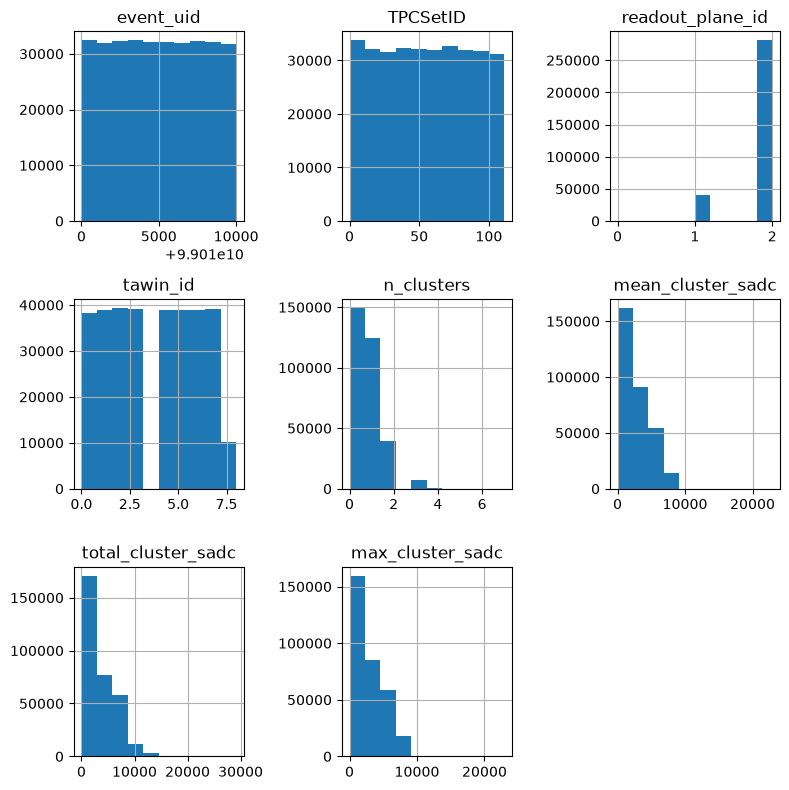

In [24]:
rad_insp_custers.hist(figsize=(8,8))
plt.tight_layout()


In [25]:
rad_insp_custers

,event_uid,TPCSetID,readout_plane_id,tawin_id,n_clusters,mean_cluster_sadc,total_cluster_sadc,max_cluster_sadc,tp_index,dbscan_label
0,99010000001,62,2,2,1,3543.0,3543,3543,"[(0, 25), (0, 31), (0, 32), (0, 34), (0, 47), ...","[-1, -1, -1, -1, -1, 0, 0]"
1,99010000001,62,2,0,0,0.0,0,0,[],[]
2,99010000001,62,2,4,0,0.0,0,0,[],[]
3,99010000001,0,2,1,1,4349.0,4349,4349,"[(0, 69), (0, 70), (0, 83), (0, 84), (0, 87)]","[0, 0, -1, -1, -1]"
4,99010000001,4,1,5,2,3780.5,7561,4923,"[(0, 100), (0, 102), (0, 103), (0, 108), (0, 1...","[-1, 0, 0, 1, 1]"
...,...,...,...,...,...,...,...,...,...,...
321506,99010010002,43,1,7,1,3156.0,3156,3156,"[(999, 5650), (999, 5651), (999, 5655), (999, ...","[-1, -1, -1, -1, 0, 0, -1]"
321507,99010010002,43,1,3,1,3406.0,3406,3406,"[(999, 5653), (999, 5654), (999, 5659), (999, ...","[-1, -1, -1, -1, 0, 0]"
321508,99010010002,43,2,5,0,0.0,0,0,[],[]
321509,99010010002,43,2,3,1,3716.0,3716,3716,"[(999, 5669), (999, 5674), (999, 5684), (999, ...","[-1, -1, -1, 0, 0]"


4.615596583080739

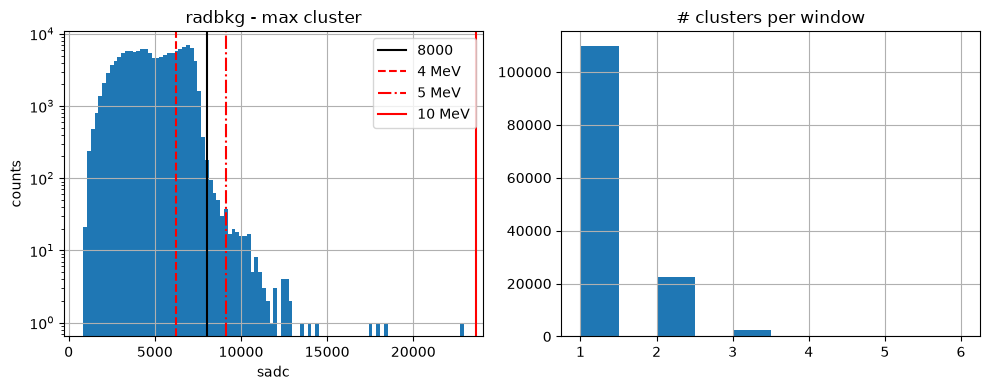

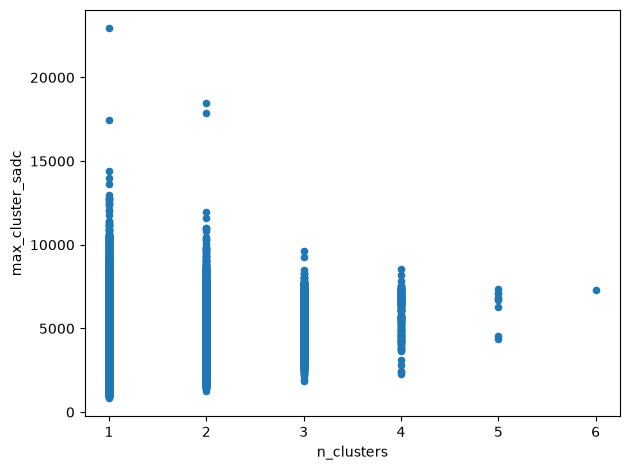

In [26]:
from tpvalidator.analysis.histograms import compute_regaxis_specs

# compute_regaxis_specs()


rad_insp_custers.query('readout_plane_id==2 & n_clusters > 0', inplace=True)

fig, axes = plt.subplots(1,2, figsize=(10,4))
ax=axes[0]
rad_insp_custers.max_cluster_sadc.hist(bins=100, ax=ax)

sadc_1Mev = 2.277e3

sadc_line = 8000
ax.axvline(x=8000, c='k', label='8000')

print(elec_calibrator.sadc_to_mev(8000))
energy = 4
ax.axvline(x=elec_calibrator.mev_to_sadc(energy), c='r', ls='--', label=f'{energy} MeV')
energy = 5
ax.axvline(x=elec_calibrator.mev_to_sadc(energy), c='r', ls='-.', label=f'{energy} MeV')
energy = 10
ax.axvline(x=elec_calibrator.mev_to_sadc(energy), c='r', ls='-', label=f'{energy} MeV')

# ax.set_yscale('log')
ax.set_xlabel('sadc')
ax.set_ylabel('counts')
ax.set_title('radbkg - max cluster')
ax.set_yscale('log')
ax.legend()

ax=axes[1]
rad_insp_custers.n_clusters.hist(ax=ax)
ax.set_title('# clusters per window')

fig.tight_layout()


fig, axes = plt.subplots(1,1)
ax=axes
rad_insp_custers.plot.scatter(x='n_clusters', y='max_cluster_sadc', ax=ax)
fig.tight_layout()
